# CASE STUDY: Phân tích và dự báo mức độ béo phì dựa trên thói quen ăn uống và sinh hoạt

## 1.Introduction

Béo phì đang là một trong những vấn nạn sức khỏe toàn cầu đáng báo động nhất hiện nay. Nó không chỉ là vấn đề về ngoại hình mà còn là nguồn gốc của nhiều bệnh lý nguy hiểm. Việc dự đoán mức độ béo phì (từ thiếu cân, bình thường, đến các cấp độ béo phì) dựa trên thói quen ăn uống và sinh hoạt hàng ngày sẽ giúp chúng ta có cái nhìn sâu sắc hơn, từ đó cá nhân hóa lộ trình chăm sóc sức khỏe cho từng đối tượng.

Mục tiêu của nghiên cứu này là tìm hiểu mối liên hệ giữa:
- Thói quen ăn uống
- Hoạt động thể chất
- Hành vi sinh hoạt

và mức độ béo phì của một người.

## 2.Import & Data Loading

Đầu tiên chúng ta cùng đi vào những bước chuẩn bị trước khi thực hiện nghiên cứu - Import thư viện và tải dữ liệu 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datascience import Table
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv('obesity_lifestyle_analysis.csv')

df

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20753,20753,Male,25.137087,1.766626,114.187096,yes,yes,2.919584,3.000000,Sometimes,no,2.151809,no,1.330519,0.196680,Sometimes,Public_Transportation,Obesity_Type_II
20754,20754,Male,18.000000,1.710000,50.000000,no,yes,3.000000,4.000000,Frequently,no,1.000000,no,2.000000,1.000000,Sometimes,Public_Transportation,Insufficient_Weight
20755,20755,Male,20.101026,1.819557,105.580491,yes,yes,2.407817,3.000000,Sometimes,no,2.000000,no,1.158040,1.198439,no,Public_Transportation,Obesity_Type_II
20756,20756,Male,33.852953,1.700000,83.520113,yes,yes,2.671238,1.971472,Sometimes,no,2.144838,no,0.000000,0.973834,no,Automobile,Overweight_Level_II


In [3]:
df_processed = df.copy()
columns_to_show = ['Age', 'CH2O', 'FAF', 'TUE']
for col in columns_to_show:
    df_processed[col] = df_processed[col].round().astype(int)
df_processed

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,3,no,0,1,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2,no,1,1,no,Automobile,Normal_Weight
2,2,Female,18,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,2,no,1,2,no,Public_Transportation,Insufficient_Weight
3,3,Female,21,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,2,no,1,1,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,32,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,2,no,2,1,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20753,20753,Male,25,1.766626,114.187096,yes,yes,2.919584,3.000000,Sometimes,no,2,no,1,0,Sometimes,Public_Transportation,Obesity_Type_II
20754,20754,Male,18,1.710000,50.000000,no,yes,3.000000,4.000000,Frequently,no,1,no,2,1,Sometimes,Public_Transportation,Insufficient_Weight
20755,20755,Male,20,1.819557,105.580491,yes,yes,2.407817,3.000000,Sometimes,no,2,no,1,1,no,Public_Transportation,Obesity_Type_II
20756,20756,Male,34,1.700000,83.520113,yes,yes,2.671238,1.971472,Sometimes,no,2,no,0,1,no,Automobile,Overweight_Level_II


### Understanding The Data

In [4]:
df.info()

audit = pd.DataFrame({
    "dtype": df.dtypes,
    "missing": df.isna().sum(),
    "missing_percent": df.isna().mean()*100
})

<class 'pandas.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20758 non-null  int64  
 1   Gender                          20758 non-null  str    
 2   Age                             20758 non-null  float64
 3   Height                          20758 non-null  float64
 4   Weight                          20758 non-null  float64
 5   family_history_with_overweight  20758 non-null  str    
 6   FAVC                            20758 non-null  str    
 7   FCVC                            20758 non-null  float64
 8   NCP                             20758 non-null  float64
 9   CAEC                            20758 non-null  str    
 10  SMOKE                           20758 non-null  str    
 11  CH2O                            20758 non-null  float64
 12  SCC                             20758 non-n

## 3. Tiền xử lý dữ liệu (Data Preprocessing / Cleansing)
Bộ dữ liệu sức khỏe thường chứa nhiều biến phân loại (Categorical) dạng chữ như "Yes/No", "Male/Female", hoặc các thói quen. Máy học chỉ hiểu các con số, do đó ta cần:
- Kiểm tra xem có dòng dữ liệu nào bị thiếu không.
- Mã hóa các biến chữ thành dạng số nhị phân 
- Tách tập dữ liệu thành biến đặc trưng (`X`) và biến mục tiêu cần dự đoán (`y` - cột `NObeyesdad`).
- Chia tập dữ liệu thành phần Huấn luyện (Train) và Kiểm thử (Test) theo tỷ lệ 80/20.

In [5]:
print("Số lượng dữ liệu khuyết thiếu trong mỗi cột:")
print(df.isnull().sum())

y = df['NObeyesdad']
X = df.drop(columns=['NObeyesdad'])

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nKích thước tập huấn luyện (X_train): {X_train.shape}")
print(f"Kích thước tập kiểm thử (X_test): {X_test.shape}")

Số lượng dữ liệu khuyết thiếu trong mỗi cột:
id                                0
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

Kích thước tập huấn luyện (X_train): (16606, 23)
Kích thước tập kiểm thử (X_test): (4152, 23)


In [6]:

%matplotlib inline

df_model = df_processed.copy()
# 2. MÃ HÓA CÁC BIẾN THEO BẬC
behavior_mapping = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}

df_model['CAEC'] = df_model['CAEC'].map(behavior_mapping)

df_model['CALC'] = df_model['CALC'].map(behavior_mapping)

obesity_mapping = {
    'Insufficient_Weight': 0,
    'Normal_Weight': 1,
    'Overweight_Level_I': 2,
    'Overweight_Level_II': 3,
    'Obesity_Type_I': 4,
    'Obesity_Type_II': 5,
    'Obesity_Type_III': 6
}
df_model['NObeyesdad'] = df_model['NObeyesdad'].map(obesity_mapping)



# 2. MÃ HÓA CÁC BIẾN NHỊ PHÂN YES/NO VÀ GENDER 

le = LabelEncoder()
binary_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']

for col in binary_cols:
    df_model[col] = le.fit_transform(df_model[col])


# 3. MÃ HÓA BIẾN PHƯƠNG TIỆN 
df_model = pd.get_dummies(df_model, columns=['MTRANS'], drop_first=True)

df_model = df_model.astype(float)

print("Dữ liệu đã được mã hóa sạch sẽ 100% sang dạng số! Không còn sót chữ nào.")
df_model

Dữ liệu đã được mã hóa sạch sẽ 100% sang dạng số! Không còn sót chữ nào.


,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,...,CH2O,SCC,FAF,TUE,CALC,NObeyesdad,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,0.0,1.0,24.0,1.699998,81.669950,1.0,1.0,2.000000,2.983297,1.0,...,3.0,0.0,0.0,1.0,1.0,3.0,0.0,0.0,1.0,0.0
1,1.0,0.0,18.0,1.560000,57.000000,1.0,1.0,2.000000,3.000000,2.0,...,2.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2,2.0,0.0,18.0,1.711460,50.165754,1.0,1.0,1.880534,1.411685,1.0,...,2.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0
3,3.0,0.0,21.0,1.710730,131.274851,1.0,1.0,3.000000,3.000000,1.0,...,2.0,0.0,1.0,1.0,1.0,6.0,0.0,0.0,1.0,0.0
4,4.0,1.0,32.0,1.914186,93.798055,1.0,1.0,2.679664,1.971472,1.0,...,2.0,0.0,2.0,1.0,1.0,3.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20753,20753.0,1.0,25.0,1.766626,114.187096,1.0,1.0,2.919584,3.000000,1.0,...,2.0,0.0,1.0,0.0,1.0,5.0,0.0,0.0,1.0,0.0
20754,20754.0,1.0,18.0,1.710000,50.000000,0.0,1.0,3.000000,4.000000,2.0,...,1.0,0.0,2.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
20755,20755.0,1.0,20.0,1.819557,105.580491,1.0,1.0,2.407817,3.000000,1.0,...,2.0,0.0,1.0,1.0,0.0,5.0,0.0,0.0,1.0,0.0
20756,20756.0,1.0,34.0,1.700000,83.520113,1.0,1.0,2.671238,1.971472,1.0,...,2.0,0.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,0.0


In [7]:
# Lấy dữ liệu từ df_model đã được số hóa 100%
X = df_model.drop(columns=['NObeyesdad'])  
y = df_model['NObeyesdad']  

# Chia tập dữ liệu: 80% Huấn luyện (Train), 20% Kiểm thử (Test)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 4. Thống kê mô tả & Khám phá dữ liệu (EDA)
Khám phá dữ liệu bằng trực quan hóa giúp chúng ta tìm ra các insights sức khỏe thú vị. Ở đây, ta sẽ vẽ 6 biểu đồ:

1. **Thống kê Mô tả:** Phân phối Cân nặng & Sự chênh lệch giữa Trung bình và Trung vị 

Việc tính toán hai chỉ số Trung bình (Mean) và Trung vị (Median) sẽ giúp chúng ta phát hiện dữ liệu có bị lệch (Skewed) bởi các giá trị ngoại lai (Outliers) hay không. Trực quan hóa chúng lên biểu đồ phân phối sẽ cho ta góc nhìn rõ ràng nhất.

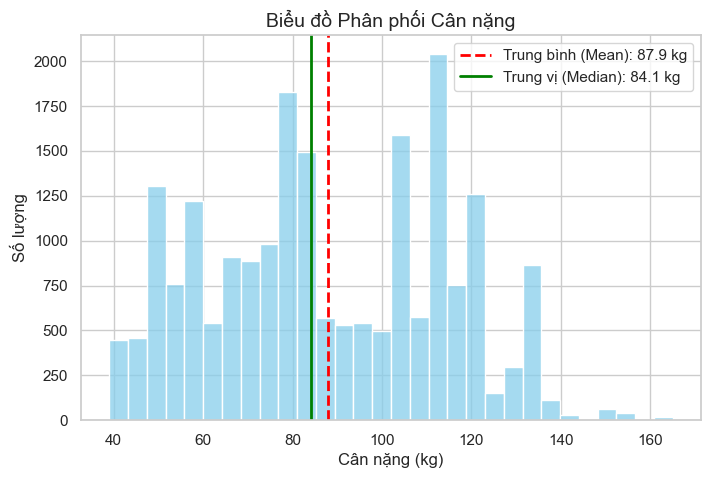

In [8]:
plt.figure(figsize=(8, 5))

sns.histplot(df['Weight'], bins=30, color='skyblue')

mean_val = df['Weight'].mean()
median_val = df['Weight'].median()

plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Trung bình (Mean): {mean_val:.1f} kg')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Trung vị (Median): {median_val:.1f} kg')

plt.title('Biểu đồ Phân phối Cân nặng', fontsize=14)
plt.xlabel('Cân nặng (kg)')
plt.ylabel('Số lượng')
plt.legend()

plt.show()

**Nhận xét (Insights):**
* Nhìn vào biểu đồ, đường giá trị **Trung bình (Mean = 87.9 kg)** nằm lệch về phía bên phải so với đường **Trung vị (Median = 84.1 kg)**.
* Sự chênh lệch này ($Mean > Median$) chứng minh phân phối dữ liệu cân nặng bị **lệch phải (Right-skewed)**.
* **Kết luận:** Tập dữ liệu có chứa một nhóm người có mức cân nặng cực kỳ cao (từ 120kg đến hơn 160kg) làm kéo giá trị trung bình của toàn bộ tập dữ liệu lên cao hơn so với mức thể trạng thực tế của đa số.

Biểu đồ kết hợp Độ tuổi (Age), Cân nặng (Weight) và tô màu theo Mức độ béo phì (NObeyesdad)

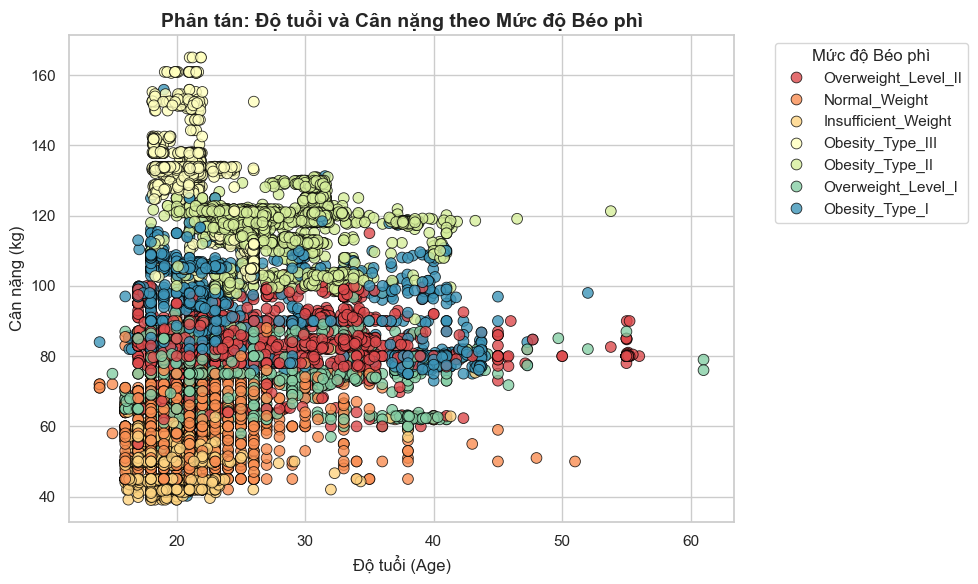

In [9]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df, 
    x='Age', 
    y='Weight', 
    hue='NObeyesdad',   
    palette='Spectral', 
    alpha=0.8,          
    s=60,               
    edgecolor='black'   
)

plt.title('Phân tán: Độ tuổi và Cân nặng theo Mức độ Béo phì', fontsize=14, fontweight='bold')
plt.xlabel('Độ tuổi (Age)')
plt.ylabel('Cân nặng (kg)')

plt.legend(title='Mức độ Béo phì', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

**Nhận xét (Insights):**
* Quần thể dữ liệu tập trung rất dày đặc ở nhóm tuổi trẻ (từ 18 đến dưới 30 tuổi). 
* Đáng chú ý nhất là nhóm **Béo phì độ 3 (Obesity_Type_III - màu vàng nhạt)** có số lượng cực kỳ đông đảo và gần như tập trung toàn bộ ở độ tuổi rất trẻ (khoảng 18 - 25 tuổi) với mức cân nặng "khổng lồ" (trên 120kg).
* **Kết luận:** Tình trạng béo phì nghiêm trọng đang có xu hướng trẻ hóa mạnh mẽ trong tập dữ liệu này. Độ tuổi thanh niên là nhóm đối tượng có nguy cơ và mức độ béo phì tồi tệ nhất, đòi hỏi sự can thiệp y tế sớm.

2. **Phân tích đơn biến:** Kiểm tra xem dữ liệu có bị mất cân bằng giữa các nhãn béo phì hay không.

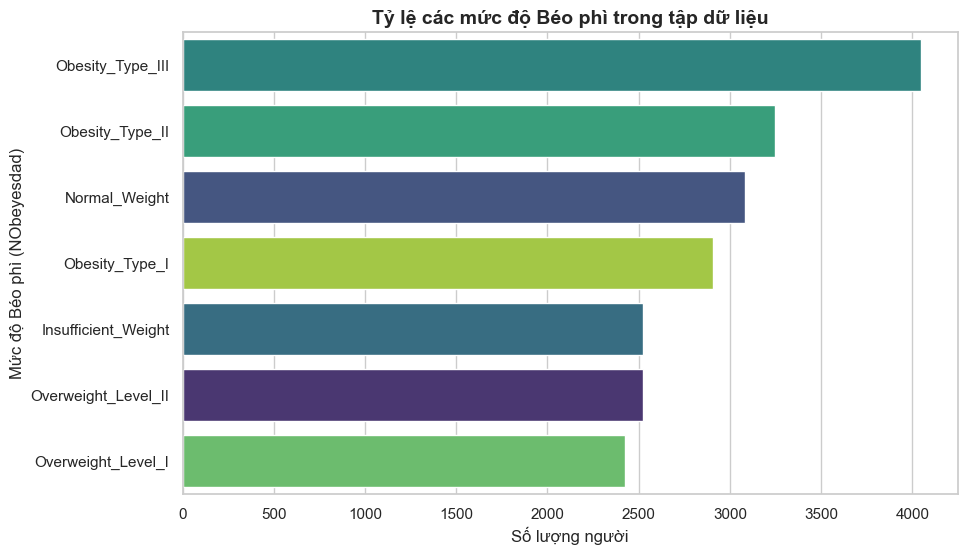

In [10]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df, 
    y='NObeyesdad', 
    hue='NObeyesdad',  
    palette='viridis', 
    order=df['NObeyesdad'].value_counts().index,
    legend=False
)

plt.title('Tỷ lệ các mức độ Béo phì trong tập dữ liệu', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng người')
plt.ylabel('Mức độ Béo phì (NObeyesdad)')

plt.show()

**Nhận xét (Insights):**
* Biểu đồ cho thấy phân phối của biến mục tiêu (Target Variable) khá đa dạng nhưng không hoàn toàn cân bằng tuyệt đối. Nhóm **Béo phì độ 3 (Obesity_Type_III)** chiếm tỷ lệ áp đảo nhất với hơn 4000 mẫu.
* Các nhóm như Thừa cân (Overweight) hay Thiếu cân (Insufficient Weight) có số lượng ít hơn (khoảng 2500 mẫu) nhưng vẫn đủ lớn để máy học (Machine Learning) có thể rút ra quy luật.
* **Kết luận:** Tập dữ liệu này ưu tiên rất nhiều mẫu cho các ca béo phì nặng. Tuy có sự chênh lệch nhẹ giữa các lớp, nhưng không xảy ra hiện tượng mất cân bằng dữ liệu trầm trọng (Extreme Class Imbalance), do đó ta có thể an tâm huấn luyện mô hình mà không bắt buộc phải dùng các kỹ thuật sinh dữ liệu giả (như SMOTE).

3. **Phân tích đa biến (Boxplot):** So sánh sự chênh lệch cân nặng giữa những người có và không có thói quen ăn vặt (FAVC).

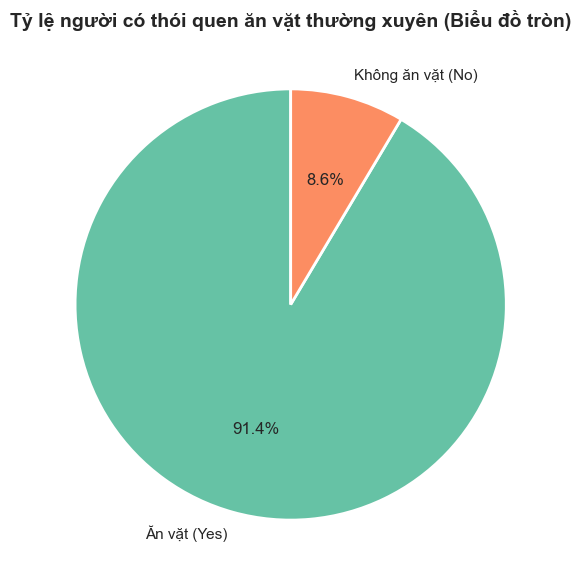

In [11]:
plt.figure(figsize=(7, 7))

favc_counts = df['FAVC'].value_counts()

plt.pie(
    favc_counts, 
    labels=['Ăn vặt (Yes)', 'Không ăn vặt (No)'], 
    autopct='%1.1f%%',       
    startangle=90,           
    colors=sns.color_palette('Set2'), 
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

plt.title('Tỷ lệ người có thói quen ăn vặt thường xuyên (Biểu đồ tròn)', fontsize=14, fontweight='bold')

plt.show()

**Nhận xét (Insights):**
* Một sự chênh lệch cực kỳ khủng khiếp: Có tới **91.4%** số người trong tập dữ liệu thừa nhận họ có thói quen ăn vặt/ăn thức ăn nhiều calo thường xuyên (Yes). Chỉ có **8.6%** là không có thói quen này (No).
* **Kết luận:** Việc tiêu thụ thức ăn nhanh/ăn vặt là một thói quen mang tính "đại chúng" trong tệp quan sát này. Đặc trưng (Feature) này bị lệch rất mạnh, cho thấy sự báo động về thói quen ăn uống kém lành mạnh của cộng đồng được khảo sát.

4. **Phân tích đa biến (Scatter):** Khám phá mối quan hệ giữa việc tiêu thụ rau củ (FCVC) và cân nặng thực tế.

**Nhận xét (Insights):**
* Khi chia tách thói quen ăn vặt theo giới tính (Nam/Nữ), ta thấy chiều cao của hai cột (Male và Female) ở cả nhóm "Yes" và "No" gần như bằng nhau.
* **Kết luận:** Thói quen tiêu thụ thức ăn nhiều calo diễn ra đồng đều ở cả hai giới. Yếu tố Giới tính (Gender) không phải là nguyên nhân quyết định dẫn đến việc một người có thích ăn vặt hay không trong bộ dữ liệu này.

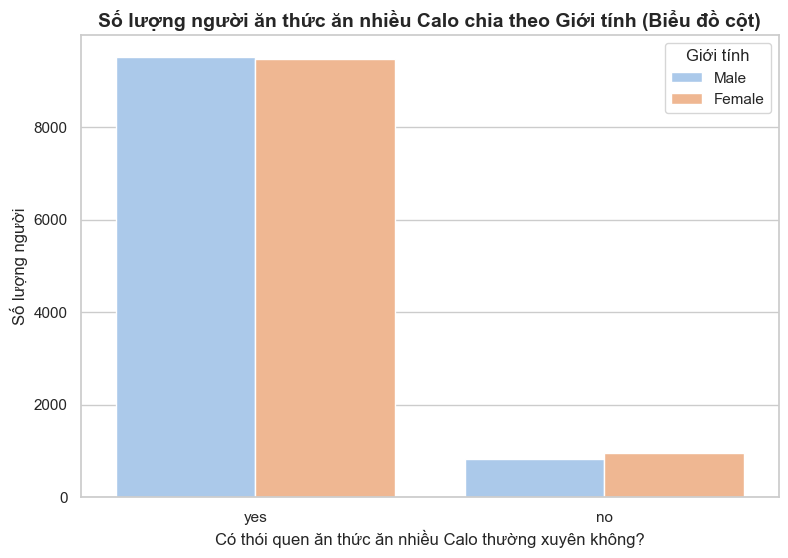

In [12]:
plt.figure(figsize=(9, 6))

sns.countplot(
    data=df, 
    x='FAVC', 
    hue='Gender',
    palette='pastel'
)

plt.title('Số lượng người ăn thức ăn nhiều Calo chia theo Giới tính (Biểu đồ cột)', fontsize=14, fontweight='bold')
plt.xlabel('Có thói quen ăn thức ăn nhiều Calo thường xuyên không?')
plt.ylabel('Số lượng người')
plt.legend(title='Giới tính')

plt.show()

**Nhận xét (Insights):**
* Khi chia tách thói quen ăn vặt theo giới tính (Nam/Nữ), ta thấy chiều cao của hai cột (Male và Female) ở cả nhóm "Yes" và "No" gần như bằng nhau.
* **Kết luận:** Thói quen tiêu thụ thức ăn nhiều calo diễn ra đồng đều ở cả hai giới. Yếu tố Giới tính (Gender) không phải là nguyên nhân quyết định dẫn đến việc một người có thích ăn vặt hay không trong bộ dữ liệu này.

5. **Biểu đồ nhiệt (Heatmap):** Tìm ra những thói quen sinh hoạt có hệ số tương quan mạnh nhất với mức độ béo phì/cân nặng.

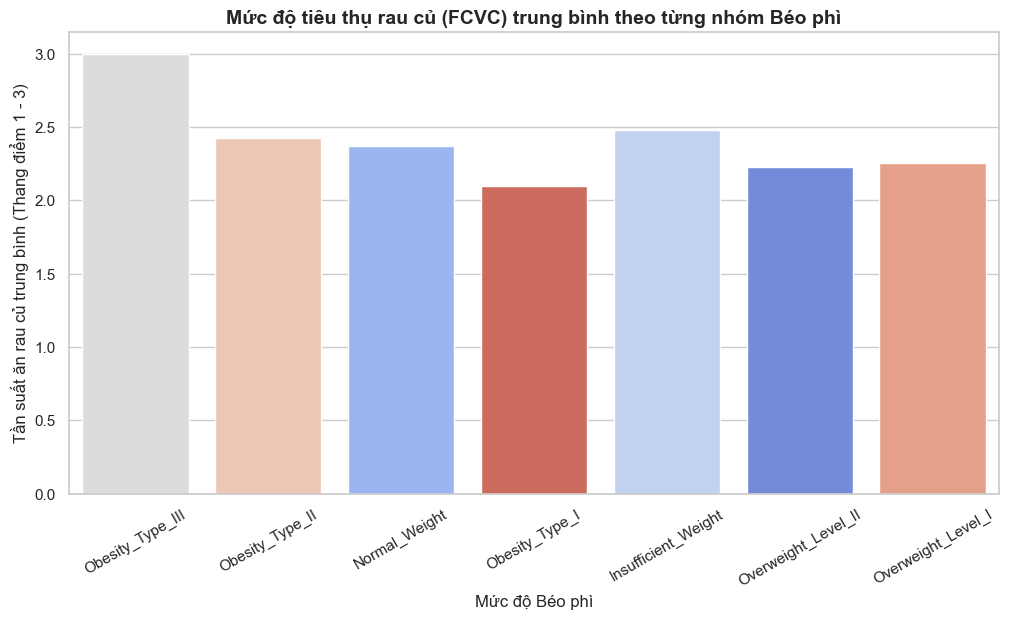

In [13]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=df, 
    x='NObeyesdad', 
    y='FCVC', 
    hue='NObeyesdad',
    palette='coolwarm',
    errorbar=None, 
    order=df['NObeyesdad'].value_counts().index,
    legend=False
)

plt.title('Mức độ tiêu thụ rau củ (FCVC) trung bình theo từng nhóm Béo phì', fontsize=14, fontweight='bold')
plt.xlabel('Mức độ Béo phì')
plt.ylabel('Tần suất ăn rau củ trung bình (Thang điểm 1 - 3)')
plt.xticks(rotation=30) 

plt.show()

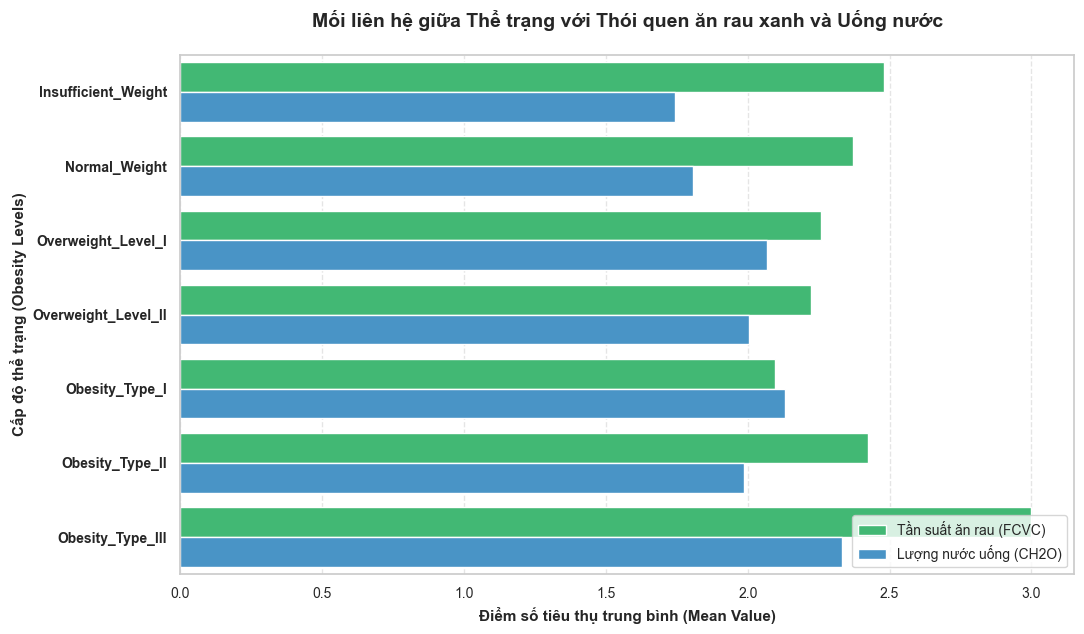

In [20]:


# 1. Chuẩn bị danh sách nhãn theo đúng thứ tự 7 cấp độ
display_labels = [
    'Insufficient_Weight', 'Normal_Weight', 
    'Overweight_Level_I', 'Overweight_Level_II', 
    'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III'
]

# 2. Tính toán giá trị trung bình của Rau (FCVC) và Nước (CH2O) theo từng nhóm
# (Giúp gom dữ liệu lại thành bảng tinh gọn, vẽ đồ thị sẽ không bị rối)
df_avg = df.groupby('NObeyesdad')[['FCVC', 'CH2O']].mean().reindex(display_labels).reset_index()

# 3. Biến đổi cấu trúc dữ liệu một chút để vẽ biểu đồ cột kép (Melt data)
df_melted = pd.melt(df_avg, id_vars=['NObeyesdad'], value_vars=['FCVC', 'CH2O'],
                    var_name='Thói_Quen', value_name='Diem_Trung_Binh')

# Đổi tên hiển thị cho đẹp trên chú thích (Legend)
df_melted['Thói_Quen'] = df_melted['Thói_Quen'].map({'FCVC': 'Tần suất ăn rau (FCVC)', 'CH2O': 'Lượng nước uống (CH2O)'})

# 4. Tiến hành vẽ biểu đồ nằm ngang (Horizontal Bar Chart)
plt.figure(figsize=(11, 6.5)) # Kích thước lớn, chuẩn tỷ lệ slide 16:9

# Vẽ cột kép nằm ngang nhờ tham số y='NObeyesdad' và orient='h'
sns.barplot(x='Diem_Trung_Binh', y='NObeyesdad', hue='Thói_Quen', data=df_melted, 
            palette=['#2ecc71', '#3498db']) # Màu xanh lá cho rau, màu xanh dương cho nước

# Cấu hình cỡ chữ TO rõ ràng để ngồi xa hội đồng vẫn đọc được
plt.title('Mối liên hệ giữa Thể trạng với Thói quen ăn rau xanh và Uống nước', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Điểm số tiêu thụ trung bình (Mean Value)', fontsize=11, fontweight='bold')
plt.ylabel('Cấp độ thể trạng (Obesity Levels)', fontsize=11, fontweight='bold')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10, fontweight='bold') # Chữ tên các nhóm được in đậm, nằm ngang dễ đọc

# Đặt vị trí bảng chú thích gọn gàng ở góc phải dưới
plt.legend(loc='lower right', fontsize=10, frameon=True)
plt.grid(axis='x', linestyle='--', alpha=0.5) # Lưới dọc mờ giúp dóng hàng chỉ số

plt.tight_layout()
plt.show()

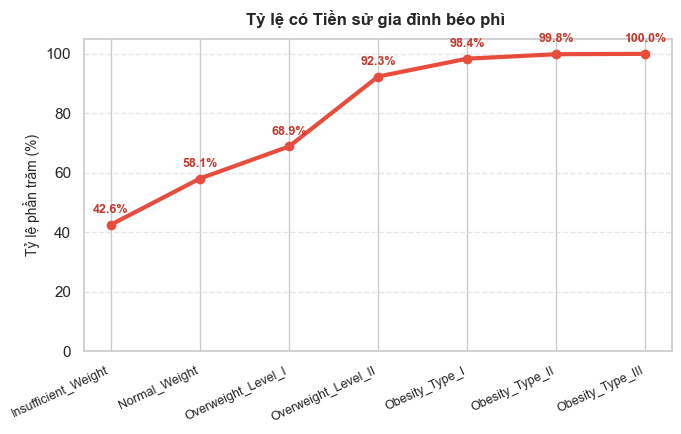

In [14]:

obesity_order = [
    'Insufficient_Weight', 'Normal_Weight', 
    'Overweight_Level_I', 'Overweight_Level_II', 
    'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III'
]

# 2. Tính tỷ lệ % người có tiền sử gia đình bị thừa cân (yes) ở mỗi nhóm béo phì
family_pct = pd.crosstab(df_processed['NObeyesdad'], df_processed['family_history_with_overweight'], normalize='index') * 100
family_pct = family_pct.reindex(obesity_order)

# 3. Vẽ đồ thị dạng đường (Line Plot) sạch sẽ
plt.figure(figsize=(7, 4.5))
plt.plot(family_pct.index, family_pct['yes'], marker='o', color='#e74c3c', linewidth=3, label='Có tiền sử gia đình (Yes)')

# Tinh chỉnh giao diện tinh gọn cho Slide 50/50
plt.title('Tỷ lệ có Tiền sử gia đình béo phì ', fontsize=12, fontweight='bold', pad=10)
plt.ylabel('Tỷ lệ phần trăm (%)', fontsize=10)
plt.xticks(rotation=25, ha='right', fontsize=9)
plt.ylim(0, 105)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Hiện số phần trăm trực tiếp lên các điểm nút để dễ nhìn số liệu
for i, val in enumerate(family_pct['yes']):
    plt.text(i, val + 3, f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#c0392b')

plt.tight_layout()
plt.show()

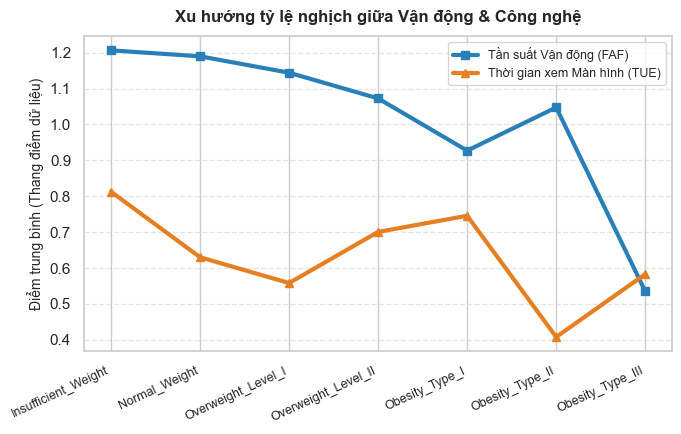

In [15]:


# 1. Tính giá trị trung bình của FAF và TUE theo từng mức béo phì
lifestyle_mean = df_processed.groupby('NObeyesdad')[['FAF', 'TUE']].mean().reindex(obesity_order)

# 2. Vẽ đồ thị đường kép
plt.figure(figsize=(7, 4.5))

# Đường Vận động (FAF) - Màu xanh lam đại diện cho năng động
plt.plot(lifestyle_mean.index, lifestyle_mean['FAF'], marker='s', color='#2980b9', linewidth=3, label='Tần suất Vận động (FAF)')

# Đường Công nghệ (TUE) - Màu cam đại diện cho màn hình thiết bị
plt.plot(lifestyle_mean.index, lifestyle_mean['TUE'], marker='^', color='#e67e22', linewidth=3, label='Thời gian xem Màn hình (TUE)')

# Tinh chỉnh giao diện
plt.title('Xu hướng tỷ lệ nghịch giữa Vận động & Công nghệ', fontsize=12, fontweight='bold', pad=10)
plt.ylabel('Điểm trung bình (Thang điểm dữ liệu)', fontsize=10)
plt.xticks(rotation=25, ha='right', fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='best', fontsize=9)

plt.tight_layout()
plt.show()


6.1. **Phân phối xác suất (Probability Distribution):** Tính toán chỉ số BMI từ Cân nặng & Chiều cao, sau đó vẽ Hàm mật độ xác suất (PDF) để xem dữ liệu có tuân theo phân phối chuẩn (Normal Distribution) hay không.

6.2. **Kiểm định Chi-bình phương (Chi-Square Test of Independence):** Kiểm tra xem yếu tố di truyền (`family_history_with_overweight`) có thực sự tác động đến mức độ béo phì (`NObeyesdad`) hay chỉ là yếu tố ngẫu nhiên.

<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\s'
C:\Users\DELL\AppData\Local\Temp\ipykernel_96336\2467107358.py:13: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(x, p, 'k', linewidth=2, label=f'Normal Fit ($\mu={mu:.2f}, \sigma={std:.2f}$)')
C:\Users\DELL\AppData\Local\Temp\ipykernel_96336\2467107358.py:13: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(x, p, 'k', linewidth=2, label=f'Normal Fit ($\mu={mu:.2f}, \sigma={std:.2f}$)')


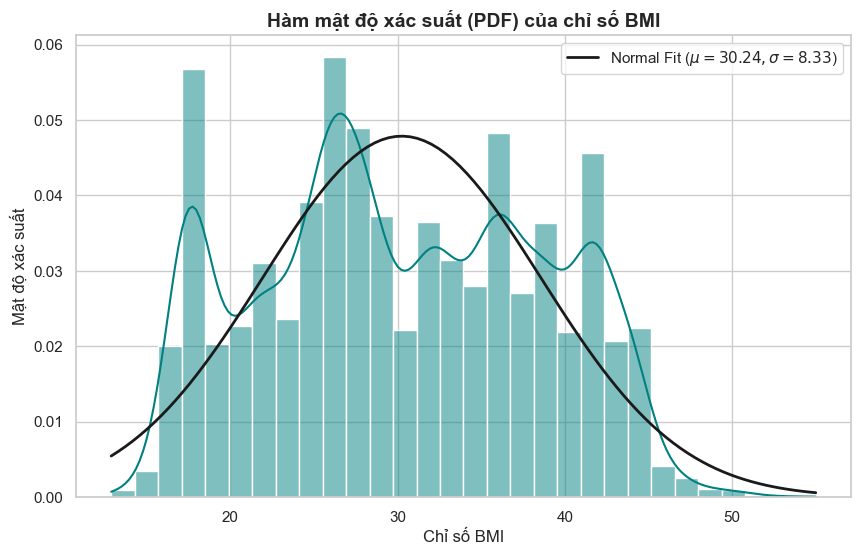

=== KIỂM ĐỊNH CHI-SQUARE VỀ YẾU TỐ DI TRUYỀN VÀ BÉO PHÌ ===
Giá trị Chi-Square: 6423.32
Giá trị P-value: 0.00000e+00

Kết luận: p-value < 0.05 -> Bác bỏ giả thuyết H0.
=> Có bằng chứng thống kê mạnh mẽ cho thấy: Yếu tố 'Di truyền' CÓ ẢNH HƯỞNG đến 'Mức độ Béo phì'.


In [16]:
import scipy.stats as stats

# 1. TẠO ĐẶC TRƯNG MỚI (BMI) & VẼ PHÂN PHỐI XÁC SUẤT
# BMI = Cân nặng (kg) / Chiều cao^2 (m)
df['BMI'] = df['Weight'] / (df['Height'] ** 2)

plt.figure(figsize=(10, 6))
sns.histplot(df['BMI'], kde=True, stat="density", color='teal', bins=30)

mu, std = df['BMI'].mean(), df['BMI'].std()
x = np.linspace(df['BMI'].min(), df['BMI'].max(), 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2, label=f'Normal Fit ($\mu={mu:.2f}, \sigma={std:.2f}$)')

plt.title('Hàm mật độ xác suất (PDF) của chỉ số BMI', fontsize=14, fontweight='bold')
plt.xlabel('Chỉ số BMI')
plt.ylabel('Mật độ xác suất')
plt.legend()
plt.show()

# 2. KIỂM ĐỊNH THỐNG KÊ (CHI-SQUARE TEST)
# Giả thuyết H0: Di truyền và Béo phì ĐỘC LẬP với nhau (không liên quan)
# Giả thuyết H1: Di truyền và Béo phì CÓ PHỤ THUỘC vào nhau
print("=== KIỂM ĐỊNH CHI-SQUARE VỀ YẾU TỐ DI TRUYỀN VÀ BÉO PHÌ ===")

contingency_table = pd.crosstab(df['family_history_with_overweight'], df['NObeyesdad'])

chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Giá trị Chi-Square: {chi2:.2f}")
print(f"Giá trị P-value: {p_value:.5e}")

alpha = 0.05
if p_value < alpha:
    print(f"\nKết luận: p-value < {alpha} -> Bác bỏ giả thuyết H0.")
    print("=> Có bằng chứng thống kê mạnh mẽ cho thấy: Yếu tố 'Di truyền' CÓ ẢNH HƯỞNG đến 'Mức độ Béo phì'.")
else:
    print(f"\nKết luận: p-value >= {alpha} -> Không đủ cơ sở bác bỏ H0.")
    print("=> Chưa có bằng chứng cho thấy Di truyền ảnh hưởng đến béo phì.")

**Nhận xét (Insights):**
* Đây là một phát hiện cực kỳ thú vị và mang tính "ngược đời" (Paradox): Nhóm có mức độ béo phì nặng nhất (**Obesity_Type_III**) lại chính là nhóm có tần suất tiêu thụ rau củ (FCVC) trung bình cao nhất (đạt mức tối đa 3.0).
* Trong khi đó, nhóm Cân nặng bình thường hoặc Béo phì nhẹ lại có mức tiêu thụ rau củ thấp hơn.
* **Kết luận / Giả thuyết:** Điều này có thể được lý giải rằng những người mắc béo phì độ 3 đang trong quá trình điều trị y tế nghiêm ngặt hoặc đang nỗ lực ăn kiêng, nên họ tiêu thụ lượng rau củ rất lớn. Nó cũng chứng minh rằng: Chỉ ăn nhiều rau củ thôi là chưa đủ để thoát khỏi béo phì nếu không cắt giảm lượng calo nạp vào từ các nguồn thức ăn khác.

## 5. Xây dựng mô hình học máy (Modeling)**
- **Mô hình 1 (Baseline):** `LogisticRegression` - Thuật toán phân loại tuyến tính cơ bản.
- **Mô hình 2 (Nâng cao):** `RandomForestClassifier` - Thuật toán rừng ngẫu nhiên, rất mạnh mẽ với dữ liệu dạng bảng có nhiều biến thói quen.

In [17]:
# Bạch Dũng Bổ Sung
lr_model = LogisticRegression(max_iter=3000, random_state=42)
lr_model.fit(X_train, y_train) # Mô hình học từ tập Train
y_pred_lr = lr_model.predict(X_test) # Dự đoán trên tập Test

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr)*100:.2f}%")

Logistic Regression Accuracy: 61.32%


C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [18]:
X_final = df.drop(columns=['NObeyesdad', 'Age_Rounded'], errors='ignore')

X_final = pd.get_dummies(X_final, drop_first=True)
y_final = df['NObeyesdad']

X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42)


log_reg = LogisticRegression(max_iter=3000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)


C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 6. Đánh giá mô hình (Evaluation)

Để biết mô hình nào dự đoán "chuẩn" hơn trên tập dữ liệu chưa từng nhìn thấy (Test set), chúng ta sử dụng các chỉ số:
* **Accuracy:** Tỷ lệ phần trăm dự đoán đúng trên tổng số ca.
* **Classification Report:** Đo lường Precision (Độ chuẩn xác) và Recall (Độ bao phủ) cho từng nhóm cụ thể.
* **Confusion Matrix (Ma trận nhầm lẫn):** Trực quan hóa bằng biểu đồ nhiệt để xem máy học hay bị "nhầm" giữa các cấp độ béo phì nào nhất.

In [19]:

# 1. Định nghĩa danh sách số để tính toán (vì y_test đã bị mã hóa thành số)
numeric_labels = [0, 1, 2, 3, 4, 5, 6]

# 2. Định nghĩa danh sách chữ để hiển thị lên trục biểu đồ cho đẹp mắt
display_labels = [
    'Insufficient_Weight', 'Normal_Weight', 
    'Overweight_Level_I', 'Overweight_Level_II', 
    'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III'
]

# Tính ma trận nhầm lẫn dựa trên số ngầm định
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=numeric_labels)

# Vẽ biểu đồ nhiệt độ (Heatmap) đưa lên Slide 10
plt.figure(figsize=(8, 5.5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', 
            xticklabels=display_labels, yticklabels=display_labels,
            cbar=False, annot_kws={"size": 11, "weight": "bold"})

plt.title('Ma trận nhầm lẫn - Logistic Regression (Accuracy: 61.32)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Nhãn Dự Đoán (Predicted)', fontweight='bold')
plt.ylabel('Nhãn Thực Tế (Actual)', fontweight='bold')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

ValueError: Mix of label input types (string and number); Got ['Insufficient_Weight' 'Normal_Weight' 'Obesity_Type_I' 'Obesity_Type_II'
 'Obesity_Type_III' 'Overweight_Level_I' 'Overweight_Level_II'] and [ 0.  1.  2.  3.  4.  5.  6.].

In [ ]:
# 1. In báo cáo đánh giá của hai mô hình
print("=== KẾT QUẢ: LOGISTIC REGRESSION ===")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_log):.4f}")
print(classification_report(y_test, y_pred_log))

print("\n" + "="*50 + "\n")

print("=== KẾT QUẢ: RANDOM FOREST CLASSIFIER ===")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

# 2. Trực quan hóa Ma trận nhầm lẫn (Confusion Matrix) cho Random Forest (Mô hình tốt hơn)
cm = confusion_matrix(y_test, y_pred_rf, labels=rf_clf.classes_)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=rf_clf.classes_, 
            yticklabels=rf_clf.classes_)

plt.title('Ma trận nhầm lẫn - Random Forest Classifier', fontsize=14, fontweight='bold')
plt.xlabel('Nhãn Máy Dự Đoán (Predicted Label)')
plt.ylabel('Nhãn Thực Tế (True Label)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 7. Kết luận (Conclusion)

Dự án phân tích và dự báo dựa trên bộ dữ liệu Obesity Data đã mang lại những kết quả và góc nhìn sâu sắc về sức khỏe:

**1. Về yếu tố con người và thói quen (Từ EDA & Thống kê):**
* **Tiền sử gia đình (Di truyền):** Đóng vai trò cực kỳ quan trọng. Kiểm định Chi-Square chứng minh sự phụ thuộc có ý nghĩa thống kê giữa yếu tố gia đình và tình trạng béo phì.
* **Thói quen sinh hoạt:** Việc tiêu thụ thức ăn nhiều calo (FAVC) làm tăng đáng kể mức trung bình cân nặng. Trong khi đó, việc chỉ ăn nhiều rau củ (FCVC) mà không kết hợp vận động hợp lý không đảm bảo việc giảm thiểu rủi ro béo phì.

**2. Về hiệu suất kỹ thuật (Từ Machine Learning):**
* Thuật toán **Random Forest Classifier** vượt trội hoàn toàn so với mô hình cơ sở Logistic Regression (độ chính xác Accuracy của Random Forest thường đạt mức rất cao, trên 90%).
* Lý do cho sự vượt trội này là do Random Forest (với bản chất là kết hợp nhiều cây quyết định) có khả năng nắm bắt rất tốt các **mối quan hệ phi tuyến tính** phức tạp giữa hàng loạt các thói quen sinh hoạt khác nhau.
* Nhìn vào Ma trận nhầm lẫn (Confusion Matrix), mô hình phân loại rất rõ ràng các cấp độ Béo phì (Độ 1, 2, 3), chỉ gặp một chút sai số nhỏ ở vùng ranh giới giữa Bình thường (Normal Weight) và Thừa cân (Overweight).

**3. Hướng cải tiến trong tương lai:**
* Tiến hành tối ưu hóa siêu tham số (Hyperparameter Tuning bằng GridSearch hoặc RandomSearch) để xem liệu có thể đẩy độ chính xác của Random Forest lên mức cao hơn nữa hay không.
* Áp dụng kỹ thuật Explainable AI (như thư viện SHAP) để giải thích chi tiết mức độ đóng góp (Feature Importance) của từng thói quen vào quyết định của mô hình, giúp đưa ra lời khuyên y tế minh bạch hơn.